In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

In [ ]:
qcfile = pd.read_csv('./data/metadata_DNA_QC.tsv.gz',index_col = [0],compression='gzip', header=0, sep='\t')
rnaqc=pd.read_csv('./data/metadata_RNA_QC.tsv.gz',sep='\t',index_col=0)

In [11]:
binc = pd.read_csv('/cndd/hex002/PsychEncode/methylation/local_methylation_backgroud/10kb_methylation_CGCH_chr1_22X.tsv.gz',index_col=[0,1,2],header=[0, 1, 2, 3, 4, 5],sep = '\t')

## Chromsome Methylation

In [12]:
sex_palette={'Female':'#F16090','Male':'#61A3D7'}

/tmp/ipykernel_1774146/2123942768.py:13: FutureWarning: The behavior of indexing on a MultiIndex with a nested sequence of labels is deprecated and will change in a future version. `series.loc[label, sequence]` will raise if any members of 'sequence' or not present in the index's second level. To retain the old behavior, use `series.index.isin(sequence, level=1)`
  binc_subset = binc.loc[
/tmp/ipykernel_1774146/2123942768.py:44: FutureWarning: The behavior of indexing on a MultiIndex with a nested sequence of labels is deprecated and will change in a future version. `series.loc[label, sequence]` will raise if any members of 'sequence' or not present in the index's second level. To retain the old behavior, use `series.index.isin(sequence, level=1)`
  binc_subset = binc.loc[
/tmp/ipykernel_1774146/2123942768.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


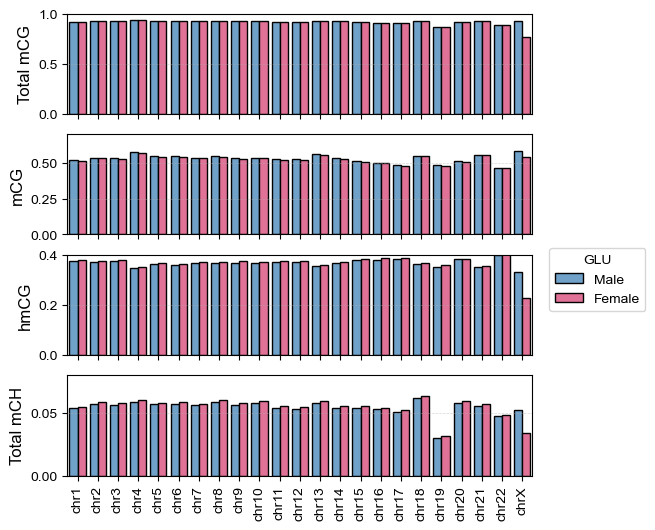

/tmp/ipykernel_1774146/2123942768.py:13: FutureWarning: The behavior of indexing on a MultiIndex with a nested sequence of labels is deprecated and will change in a future version. `series.loc[label, sequence]` will raise if any members of 'sequence' or not present in the index's second level. To retain the old behavior, use `series.index.isin(sequence, level=1)`
  binc_subset = binc.loc[
/tmp/ipykernel_1774146/2123942768.py:44: FutureWarning: The behavior of indexing on a MultiIndex with a nested sequence of labels is deprecated and will change in a future version. `series.loc[label, sequence]` will raise if any members of 'sequence' or not present in the index's second level. To retain the old behavior, use `series.index.isin(sequence, level=1)`
  binc_subset = binc.loc[
/tmp/ipykernel_1774146/2123942768.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


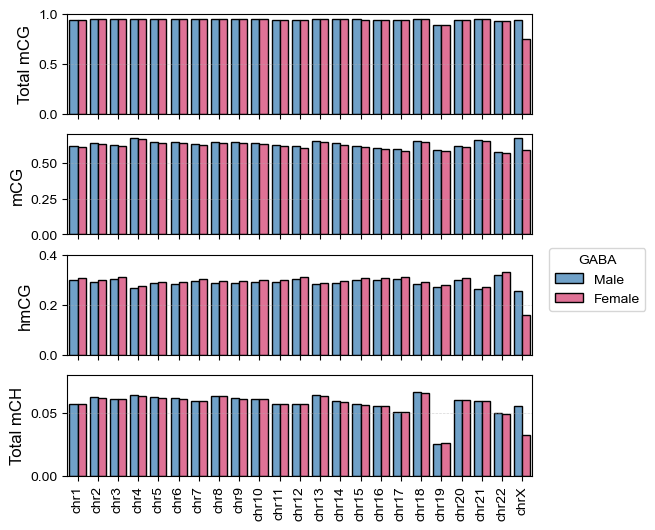

In [13]:
chromosomes = ['chr' + str(i) for i in range(1, 23)] + ['chrX']
modality_order = ['Total mCG', 'mCG', 'hmCG', 'mCH']
sex_order = ['Male', 'Female']
ylimts = [(0,1),(0,0.7),(0,0.4),(0,0.08)]
for celltype in ['GLU','GABA']:
    period = 'Late_Adulthood'

    donors = np.unique(qcfile[(qcfile['celltype'] == celltype) & 
                              (qcfile['period'] == period) ]['donor'].values)

    data_list = []
    ctxt = 'mCG'
    binc_subset = binc.loc[
        (slice(None), slice(None), slice(None)),
        (donors, slice(None), slice(None), slice(None), slice(None), ctxt)
    ].groupby(level=[1, 3, 4], axis=1).mean()

    # Extract BS, OXBS, and calculate hmC
    BS = binc_subset.loc[:, (slice(None), celltype, 'BS')]
    OXBS = binc_subset.loc[:, (slice(None), celltype, 'OXBS')]
    hmC = BS - OXBS.values

    for sex in sex_order:
        # Calculate mean levels for each chromosome
        BS_mean = BS.loc[:, sex].groupby(level=0).median().reset_index()
        BS_mean.columns = ['chr', 'methylation']
        BS_mean['Measurement'] = 'Total mCG'
        BS_mean['Sex'] = sex

        OXBS_mean = OXBS.loc[:, sex].groupby(level=0).median().reset_index()
        OXBS_mean.columns = ['chr', 'methylation']
        OXBS_mean['Measurement'] = 'mCG'
        OXBS_mean['Sex'] = sex

        hmC_mean = hmC.loc[:, sex].groupby(level=0).median().reset_index()
        hmC_mean.columns = ['chr', 'methylation']
        hmC_mean['Measurement'] = 'hmCG'
        hmC_mean['Sex'] = sex

        data_list.extend([BS_mean, OXBS_mean, hmC_mean])

    ### CH Context
    ctxt = 'mCH'
    binc_subset = binc.loc[
        (slice(None), slice(None), slice(None)),
        (donors, slice(None), slice(None), slice(None), slice(None), ctxt)
    ].groupby(level=[1, 3, 4], axis=1).mean()

    CH = binc_subset.loc[:, (slice(None), celltype, 'BS')]

    for sex in sex_order:
        CH_mean = CH.loc[:, sex].groupby(level=0).median().reset_index()
        CH_mean.columns = ['chr', 'methylation']
        CH_mean['Measurement'] = 'mCH'
        CH_mean['Sex'] = sex

        data_list.append(CH_mean)

    # Combine all data into a single DataFrame
    methylation_df = pd.concat(data_list, ignore_index=True)
    fig, axs = plt.subplots(4, 1, figsize=(6, 6), sharex=True, gridspec_kw={'hspace': 0.2})
    # plt.tight_layout(rect=[0, 0, 0.98, 1])

    for idx, (modality,ylimt) in enumerate(zip(modality_order,ylimts)):
        ax = axs[idx]
        subset_df = methylation_df[methylation_df['Measurement'] == modality]

        sns.barplot(
            data=subset_df,
            x='chr',
            y='methylation',
            hue='Sex',
            palette=sex_palette,
            ax=ax,
            edgecolor='black',
            order=chromosomes,                
            ci=None
        )
        ax.set_xlim(-0.5, len(chromosomes) - 0.5)
        # Set x-ticks only for the bottom row
        if idx == 3:
            ax.set_xticks(range(len(chromosomes) ))
            ax.set_xticklabels(chromosomes, rotation=90, fontsize=10)
        else:
            ax.set_xticks([])

        # Axis labels and title
        ax.set_ylabel(modality.replace('mCH','Total mCH'), fontsize=12)
        ax.get_legend().remove()
        ax.set_title(f'', fontsize=14, fontweight='bold')
        ax.set_ylim(ylimt)
        ax.set_xlabel('')
        ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)

    # Legend
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, title=f'{celltype}', loc='upper right', bbox_to_anchor=(1.1, 0.5), fontsize=10, title_fontsize=10)


    plt.tight_layout()
    # plt.savefig(f'{celltype}_{period}_chr_methy_boxplot.pdf')
    plt.show()


## ChrX Methylation per Individual Donor

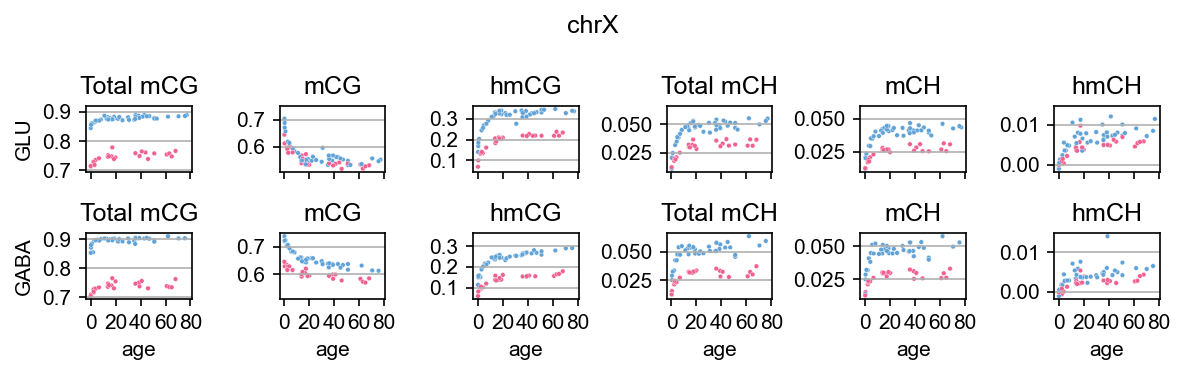

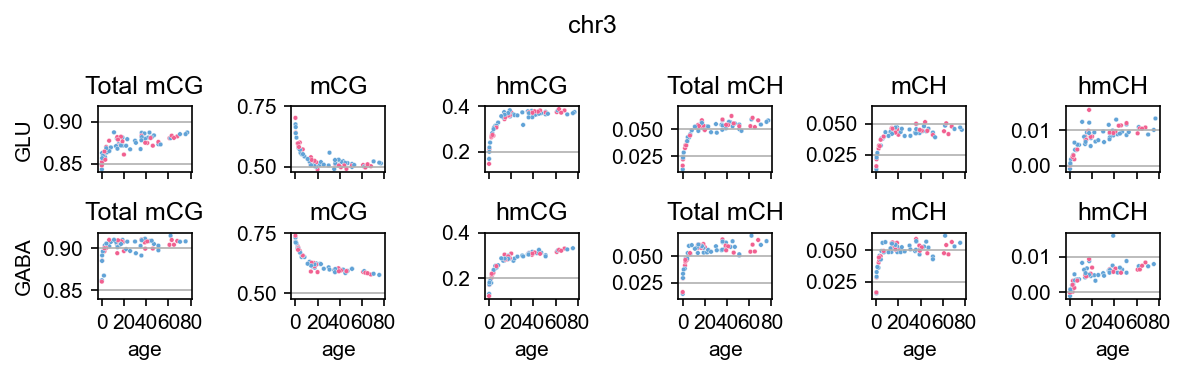

In [14]:
chrm = pd.read_csv('/cndd2/jchien/project/Dracheva_Development/Individual_globalMethylation_rmSNPs_rmblacklist_10kbbin_c100_separatechrom_mean.tsv.gz', 
                   sep='\t', index_col=0, header=[0,1])


for chrom in ['chrX', 'chr3']:
    chrxm = chrm.xs(chrom, axis=1)
    chrxm = chrxm.join(qcfile[(qcfile['DNA_passQC'] == 'True')][['age', 'sex', 'celltype', 'assay']], how='inner')
    chrxm['donor'] = chrxm.index.str.split('_').str[0]

    chrxm_dict = {}
    for mctype in ['CG', 'CH']:
        df = chrxm.pivot(index=['celltype', 'donor', 'age', 'sex'], columns='assay', values=f'm{mctype}level').reset_index().rename(columns={'BS': f'Total m{mctype}', 'OXBS': f'm{mctype}'})
        df[f'hm{mctype}'] = df[f'Total m{mctype}'] - df[f'm{mctype}']
        chrxm_dict[mctype] = df

    fig, axs = plt.subplots(2, 6, figsize=(8, 2.5), dpi=150, sharey='col', sharex=True)

    for j, celltype in enumerate(['GLU', 'GABA']):
        for k, mctype in enumerate(['CG', 'CH']):
            df = chrxm_dict[mctype]
            for i, assay in enumerate([f'Total m{mctype}', f'm{mctype}', f'hm{mctype}']):
                ax = axs[j, k*3 + i]  # Position: k*3+i to place CG and CH side by side
                sns.scatterplot(data=df[(df['celltype'] == celltype)], x='age', y=assay, hue='sex', palette=sex_palette, s=5, ax=ax)
                ax.set_title(f'{assay}')
                ax.set_ylabel('')
                ax.set_xticks([0,20,40,60,80])
                ax.legend().remove()
                ax.grid(axis='y')
                if i == 0 and k == 0: 
                    ax.set_ylabel(f'{celltype}')

    plt.suptitle(chrom)
    plt.tight_layout()
    # plt.savefig(f'/cndd/hex002/PsychEncode/Figures/chrX_regionmethylation_bin_{chrom}.pdf', bbox_inches='tight')
    plt.show()

## Escape/Inactivte Gene Methylation across Age Group

In [15]:
period_order=['Infancy', 'Early_Childhood', 'Late_Childhood', 'Adolescence', 'Adulthood','Late_Adulthood']

In [ ]:
gene_meta=pd.read_csv('./data/gencode.v37.annotation.intragenic_filter.bed.gz',
                      names=['chr','start','end','gene_id','strand','tmp','gene_name','fn'],
                      index_col='gene_id', sep='\t')
gene_meta['len']=gene_meta['end']-gene_meta['start']            
genedict_nametoid=dict(zip(gene_meta.gene_name, gene_meta.index))
genedict_idtoname=dict(zip(gene_meta.index, gene_meta.gene_name))

rnaexp=pd.read_csv('./data/RNA_expression_log2CPM+1.tsv.gz',sep='\t',index_col=0)
rnaexp=rnaexp[rnaqc[rnaqc['RNA_passQC']].index]
rnaexp.index = rnaexp.index.map(genedict_idtoname)
rnaexp=rnaexp[rnaexp.mean(axis=1)>2]

escapee=pd.read_csv('./data/2017_GTX_escapee_table1.csv.gz',index_col='Gene name')
print(len(escapee))
print(escapee['Combined XCI status'].value_counts())
# escapee.index=escapee.index.str.split('.').str[0]
escapee = escapee[~escapee.index.duplicated(keep='first')]
# ref=escapee_mukamel[['Note']].join(escapee[['Combined XCI status']],how='outer')
ref=escapee[['Combined XCI status']]

ref = ref.rename(columns={'Combined XCI status':'XCI status'})
ref=ref[ref.index.notna()].replace(np.nan,'no annotation')
print(len(ref))


ref = ref.loc[list(set(ref.index).intersection(set(rnaexp.index)))]

631
inactive    431
variable    101
escape       99
Name: Combined XCI status, dtype: int64
631


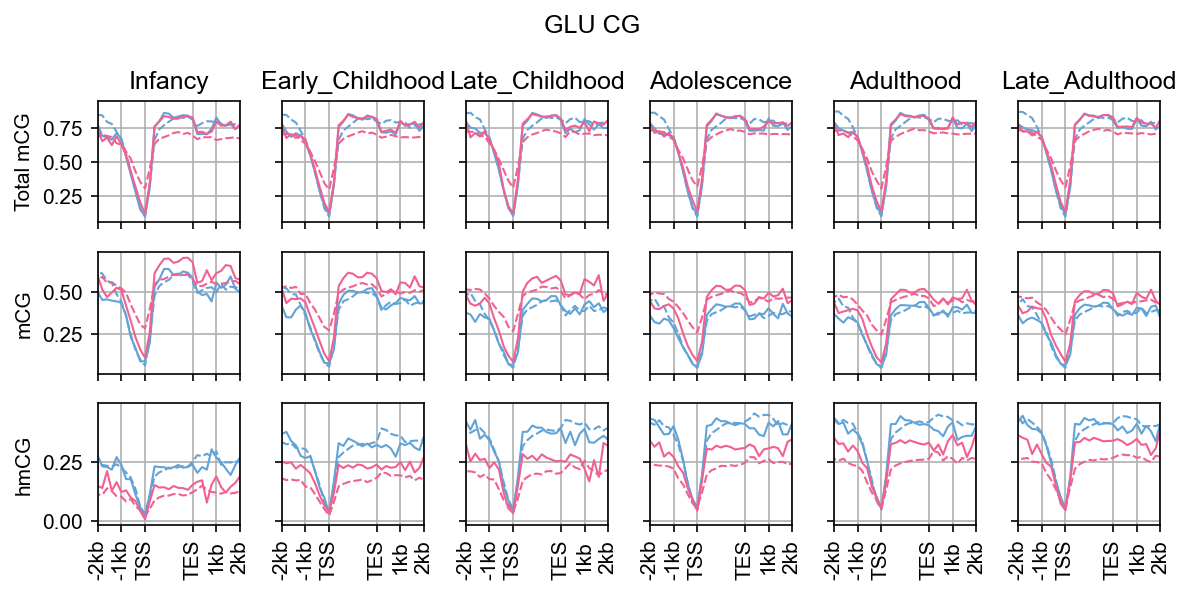

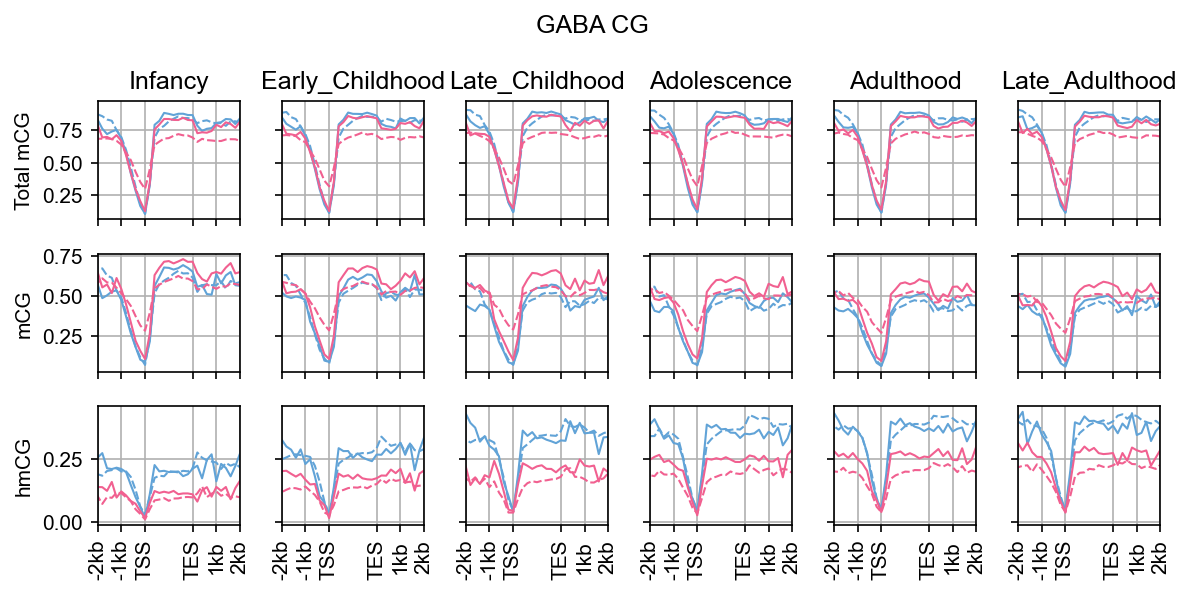

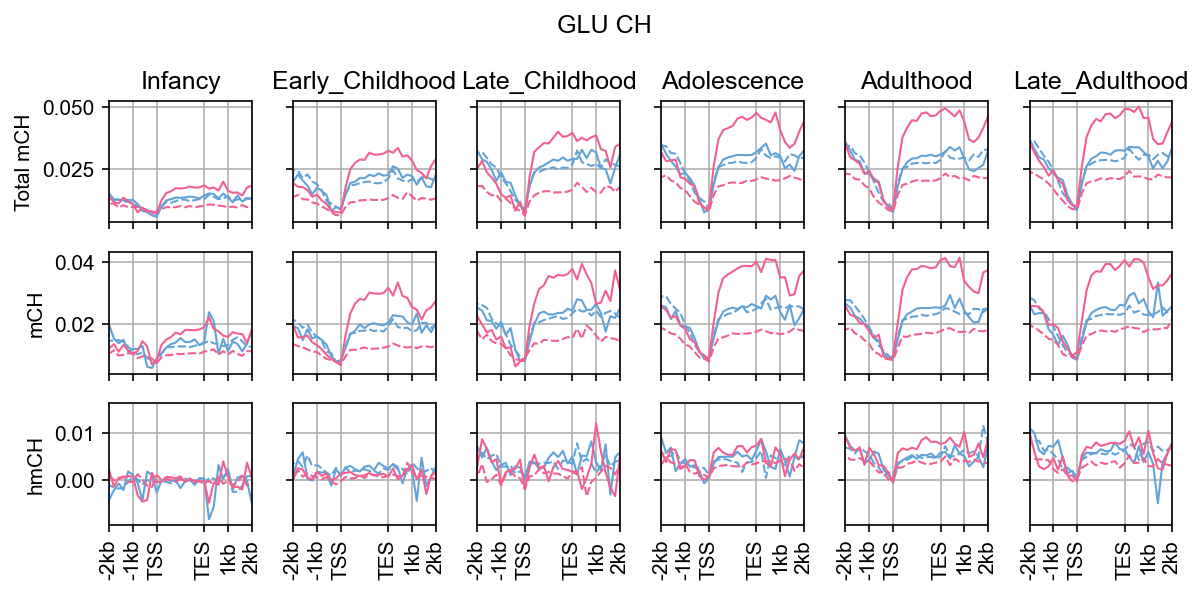

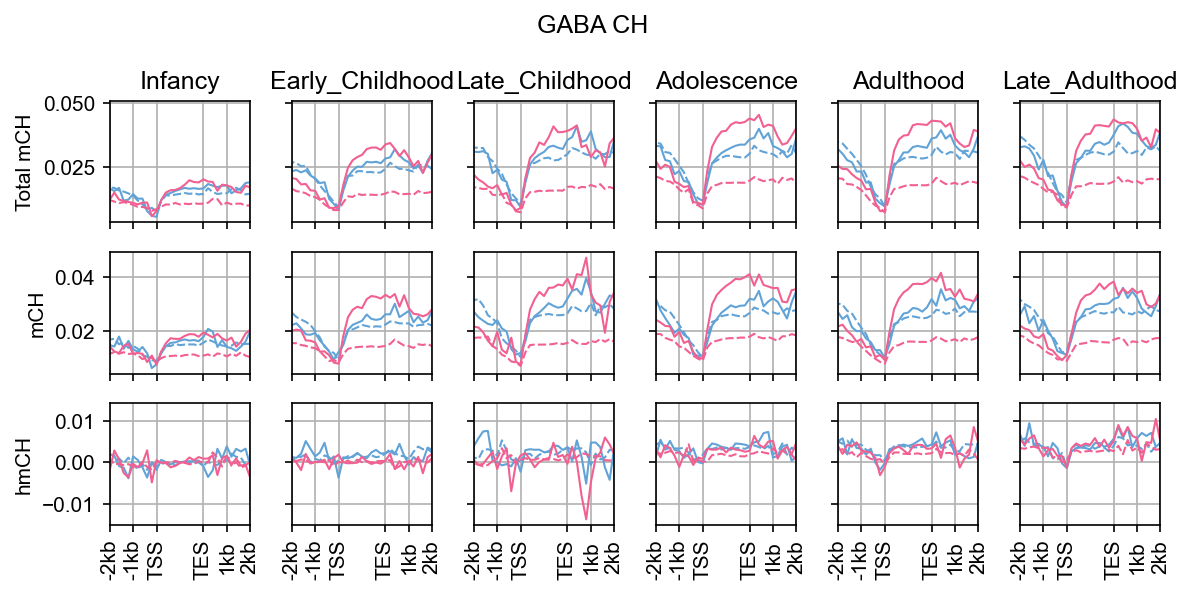

In [18]:
for mctype in ['CG', 'CH']:
    for celltype in ['GLU', 'GABA']:
        fig, axs = plt.subplots(3, len(period_order), figsize=(8, 4), dpi=150, sharey='row', sharex=True)
        for p, period in enumerate(period_order):
            bs = []
            ox = []
            hmc = []
            for sex in ['Male', 'Female']:
                bs_tmp = pd.read_csv(f'/cndd2/jchien/project/Dracheva_Development/regionMethylation/flanking/chrX_genebody_200_5kb/{celltype}_BS_{period}_{sex}.genebody_chrX_{mctype}N-Both.sparse.bed.gz',
                                     names=['chr', 'start', 'end', 'dmr', 'bin', 'bin_num', 'mc', 'c'], sep='\t', index_col=['dmr'])
                ox_tmp = pd.read_csv(f'/cndd2/jchien/project/Dracheva_Development/regionMethylation/flanking/chrX_genebody_200_5kb/{celltype}_OXBS_{period}_{sex}.genebody_chrX_{mctype}N-Both.sparse.bed.gz',
                                     names=['chr', 'start', 'end', 'dmr', 'bin', 'bin_num', 'mc', 'c'], sep='\t', index_col=['dmr'])

                bs_tmp[sex] = bs_tmp['mc'] / bs_tmp['c']
                ox_tmp[sex] = ox_tmp['mc'] / ox_tmp['c']
                hmc_tmp = bs_tmp.reset_index().set_index(['dmr', 'bin', 'bin_num'])[[sex]].sub(ox_tmp.reset_index().set_index(['dmr', 'bin', 'bin_num']))[[sex]].reset_index(['bin', 'bin_num'])

                bs_tmp = bs_tmp.join(ref)
                bs_tmp = bs_tmp.groupby(['XCI status', 'bin', 'bin_num'])[[sex]].mean() #removed CGI
                ox_tmp = ox_tmp.join(ref)
                ox_tmp = ox_tmp.groupby(['XCI status', 'bin', 'bin_num'])[[sex]].mean() #removed CGI
                hmc_tmp = hmc_tmp.join(ref)
                hmc_tmp = hmc_tmp.groupby(['XCI status', 'bin', 'bin_num'])[[sex]].mean() #removed CGI

                bs.append(bs_tmp[sex])
                ox.append(ox_tmp[sex])
                hmc.append(hmc_tmp[sex])
            bs = pd.DataFrame(bs).T
            ox = pd.DataFrame(ox).T
            hmc = pd.DataFrame(hmc).T

            del bs_tmp, ox_tmp
            bs = bs.stack().to_frame(f'Total m{mctype}').reset_index().rename(columns={'level_3': 'sex'}) #changed level_4 to level_3
            ox = ox.stack().to_frame(f'm{mctype}').reset_index().rename(columns={'level_3': 'sex'}) #changed level_4 to level_3
            hmc = hmc.stack().to_frame(f'hm{mctype}').reset_index().rename(columns={'level_3': 'sex'}) #changed level_4 to level_3

            for i in range(3):
                ax = axs[i, p]
                if i == 0:
                    sns.lineplot(data=bs[(bs['XCI status'].isin(['escape', 'inactive']))], x='bin_num', y=f'Total m{mctype}', hue='sex', palette=sex_palette, style='XCI status', ci=None, linewidth=1, ax=ax)
                elif i == 1:
                    sns.lineplot(data=ox[(ox['XCI status'].isin(['escape', 'inactive']))], x='bin_num', y=f'm{mctype}', hue='sex', palette=sex_palette, style='XCI status', ci=None, linewidth=1, ax=ax)
                else:
                    sns.lineplot(data=hmc[(hmc['XCI status'].isin(['escape', 'inactive']))], x='bin_num', y=f'hm{mctype}', hue='sex', palette=sex_palette, style='XCI status', linewidth=1, ci=None, ax=ax)

                ax.set_xticks(ticks=[0, 15, 20, 25, 35, 40, 45, 60], labels=['-5kb', '-2kb', '-1kb', 'TSS', 'TES', '1kb', '2kb', '5kb'], rotation=90)
                ax.set_xlim([15, 45])
                ax.legend().remove()
                ax.set_xlabel('')
                ax.grid()
            axs[0, p].set_title(f'{period}')
        plt.suptitle(f'{celltype} {mctype}')
        plt.tight_layout()
        # plt.savefig(f'/cndd2/jchien/project/Dracheva_Development/Figure/xinactivation_metagene_{celltype}_{mctype}.pdf',bbox_inches='tight')

## chrX methylation by mCH-defined Xi/Xa-like read class

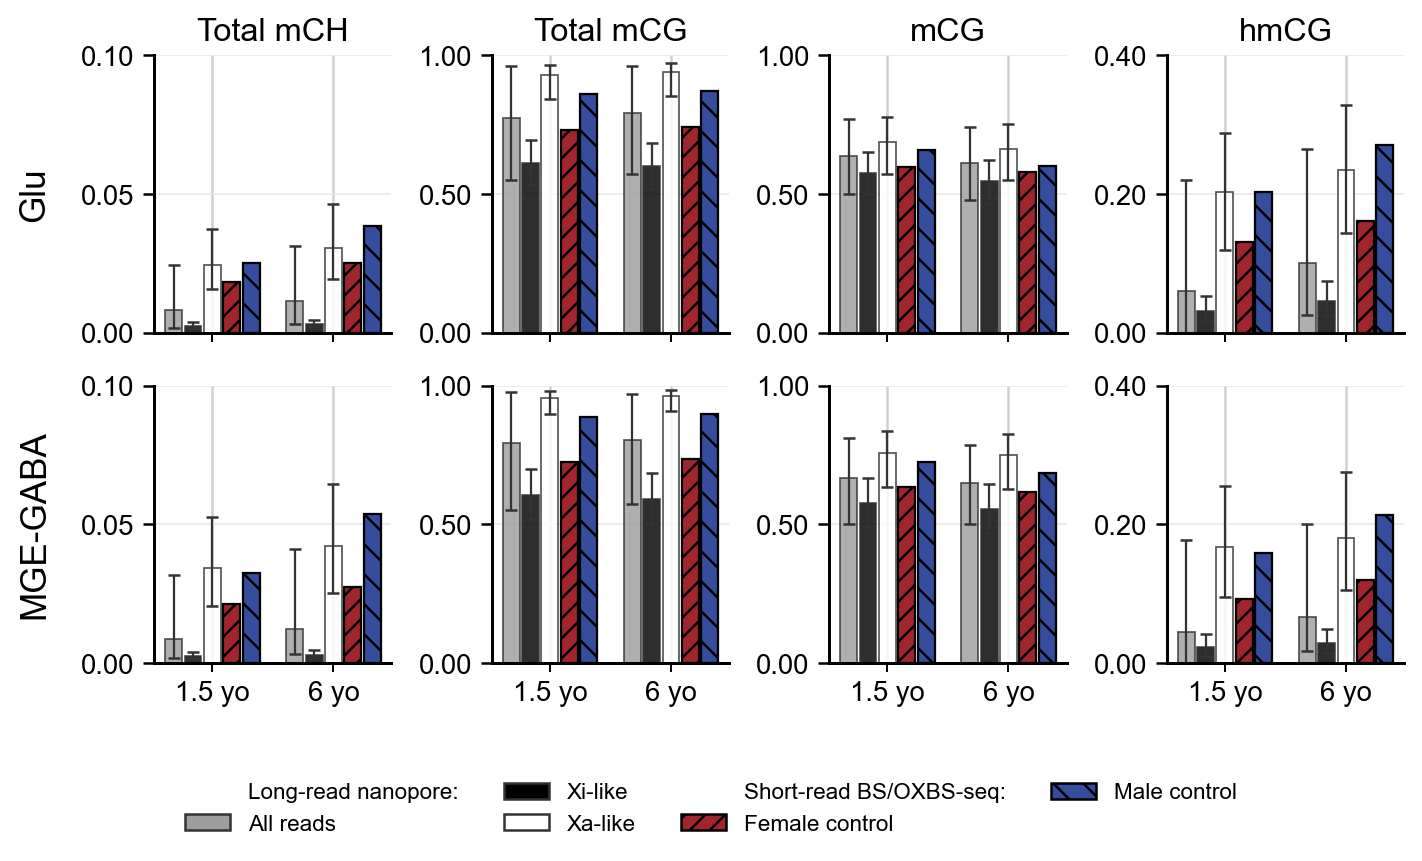

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter

read_level_file = Path('./data/Figure3_chrX_methylation_read_level.tsv.gz')
control_file = Path('./data/Figure3_chrX_methylation_controls.tsv')
read_df = pd.read_csv(read_level_file, sep='\t', dtype={'sample': str})
control_df = pd.read_csv(
    control_file, sep='\t', dtype={'sample': str, 'control_subject': str}
)

sample_order = ['5652', '5977']
sample_ages = {'5652': 1.5, '5977': 6.0}
celltype_order = ['Glu', 'GABA']
metrics = {
    'total_mCH_level': 'Total mCH',
    'mCG_fraction': 'Total mCG',
    'mCG_only_fraction': 'mCG',
    'hmCG_fraction': 'hmCG',
}
posterior_threshold = 0.8

# Calculate the plotted read-level medians and interquartile ranges.
summary_rows = []
for sample in sample_order:
    for celltype in celltype_order:
        library = read_df.loc[
            read_df['sample'].eq(sample) & read_df['celltype'].eq(celltype)
        ]
        confident = (
            library['classifier_status'].eq('fit')
            & library['bb_posterior'].ge(posterior_threshold)
        )
        for metric in metrics:
            for read_class in ['All_reads', 'Xi_like', 'Xa_like']:
                if read_class == 'All_reads':
                    values = library[metric].dropna().to_numpy()
                else:
                    values = library.loc[
                        confident & library['bb_label'].eq(read_class), metric
                    ].dropna().to_numpy()
                q25, median, q75 = np.quantile(values, [0.25, 0.50, 0.75])
                summary_rows.append({
                    'sample': sample,
                    'age': sample_ages[sample],
                    'celltype': celltype,
                    'class': read_class,
                    'metric': metric,
                    'median': median,
                    'q25': q25,
                    'q75': q75,
                    'n_reads': values.size,
                })

read_summary_df = pd.DataFrame(summary_rows)
plot_df = pd.concat([read_summary_df, control_df], ignore_index=True, sort=False)
ylims = {
    'total_mCH_level': (0.0, 0.10),
    'mCG_fraction': (0.0, 1.00),
    'mCG_only_fraction': (0.0, 1.00),
    'hmCG_fraction': (0.0, 0.40),
}
classes = ['All_reads', 'Xi_like', 'Xa_like', 'Female_control', 'Male_control']
offsets = {
    'All_reads': -0.32,
    'Xi_like': -0.16,
    'Xa_like': 0.00,
    'Female_control': 0.16,
    'Male_control': 0.32,
}
colors = {
    'All_reads': '#9E9E9E',
    'Xi_like': '#000000',
    'Xa_like': '#FFFFFF',
    'Female_control': '#A0252C',
    'Male_control': '#364C9C',
}
hatches = {'Female_control': '///', 'Male_control': '\\\\'}
bar_width = 0.14

fig, axes = plt.subplots(
    len(celltype_order),
    len(metrics),
    figsize=(8.0, 4.8),
    dpi=180,
    constrained_layout=False,
)

for row_index, celltype in enumerate(celltype_order):
    for column_index, (metric, title) in enumerate(metrics.items()):
        ax = axes[row_index, column_index]
        for sample_index, sample in enumerate(sample_order):
            for read_class in classes:
                selected = plot_df.loc[
                    plot_df['sample'].eq(sample)
                    & plot_df['celltype'].eq(celltype)
                    & plot_df['metric'].eq(metric)
                    & plot_df['class'].eq(read_class)
                ]
                if selected.shape[0] != 1:
                    raise ValueError(
                        f'Expected one summary row for {sample}, {celltype}, '
                        f'{metric}, {read_class}; found {selected.shape[0]}'
                    )
                row = selected.iloc[0]
                bar_kwargs = {
                    'x': sample_index + offsets[read_class],
                    'height': row['median'],
                    'width': bar_width,
                    'color': colors[read_class],
                    'edgecolor': '#000000' if read_class.endswith('_control') else '0.2',
                    'linewidth': 0.9 if read_class.endswith('_control') else 0.7,
                }
                if read_class.endswith('_control'):
                    bar_kwargs['hatch'] = hatches[read_class]
                else:
                    bar_kwargs.update({
                        'yerr': np.array([[
                            row['median'] - row['q25']
                        ], [
                            row['q75'] - row['median']
                        ]]),
                        'alpha': 0.82,
                        'capsize': 2.5,
                        'error_kw': {'elinewidth': 0.9, 'ecolor': '0.2'},
                    })
                ax.bar(**bar_kwargs)

        ax.set_xticks(range(len(sample_order)))
        if row_index == len(celltype_order) - 1:
            ages = [plot_df.loc[plot_df['sample'].eq(sample), 'age'].iloc[0] for sample in sample_order]
            ax.set_xticklabels([f'{age:g} yo' for age in ages], fontsize=11, color='#000000')
        else:
            ax.set_xticklabels([])
        ax.set_title(title if row_index == 0 else '', fontsize=13, color='#000000', pad=6)
        ax.set_ylabel(
            ('Glu' if celltype == 'Glu' else 'MGE-GABA') if column_index == 0 else '',
            fontsize=14,
            color='#000000',
            labelpad=12,
        )
        ymin, ymax = ylims[metric]
        ax.set_ylim(ymin, ymax)
        ax.set_yticks(np.linspace(ymin, ymax, 3))
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax.tick_params(axis='y', colors='#000000', labelsize=11, direction='out', length=4.5, width=1.0)
        ax.grid(axis='y', color='#E6E6E6', linewidth=0.6)
        ax.grid(axis='x', color='#D0D0D0', linewidth=1.0)
        ax.set_axisbelow(True)
        ax.spines[['top', 'right']].set_visible(False)
        ax.spines[['left', 'bottom']].set_color('#000000')
        ax.spines[['left', 'bottom']].set_linewidth(1.2)

fig.legend(
    handles=[
        Patch(facecolor='none', edgecolor='none', label='Long-read nanopore:'),
        Patch(facecolor=colors['All_reads'], edgecolor='0.2', label='All reads'),
        Patch(facecolor=colors['Xi_like'], edgecolor='0.2', label='Xi-like'),
        Patch(facecolor=colors['Xa_like'], edgecolor='0.2', label='Xa-like'),
        Patch(facecolor='none', edgecolor='none', label='Short-read BS/OXBS-seq:'),
        Patch(facecolor=colors['Female_control'], edgecolor='#000000', hatch='///', label='Female control'),
        Patch(facecolor=colors['Male_control'], edgecolor='#000000', hatch='\\\\', label='Male control'),
    ],
    frameon=False,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.0),
    ncol=4,
    fontsize=9,
)
fig.tight_layout(rect=(0.0, 0.14, 1.0, 1.0))

# fig.savefig('Figure3_chrX_methylation_Xi_Xa.pdf', bbox_inches='tight')
plt.show()
